# **BA3002 — Business Data and Text Mining**
## Week 6: Classification and Predictive Data Mining



---



# 📘 Naïve Bayes Algorithm

## 🎯 Learning Objective

By the end of this example, you should be able to:

- Understand what Naïve Bayes does
- Understand prior and conditional probabilities
- Calculate Naïve Bayes manually
- Compare probability scores
- Predict the class of a new observation
- Understand the zero-probability problem

---

# 1. What is Naïve Bayes?

**Naïve Bayes** is a probability-based **classification algorithm**.

It predicts the class of a new observation by asking:

> **Which class is most likely given the information we have?**

For example, Naïve Bayes can predict:

| Problem | Classes |
|---|---|
| Email filtering | Spam / Not Spam |
| Customer behavior | Buy / Not Buy |
| Sentiment analysis | Positive / Negative |
| Loan risk | High Risk / Low Risk |
| Student performance | Pass / Fail |

---

# 2. Why is it Called "Naïve"?

Naïve Bayes makes an important simplifying assumption:

> **The features are conditionally independent given the class.**

For example, suppose we predict loan risk using:

- Income
- Credit Score
- Employment

Naïve Bayes calculates the contribution of these features separately when predicting a class.

This assumption is not always completely true in real-world data, but Naïve Bayes can still work very well, especially for **text classification**.

---

# 3. Bayes' Theorem

Naïve Bayes is based on **Bayes' Theorem**:

$$
P(C \mid X) =
\frac{P(X \mid C) \times P(C)}
{P(X)}
$$

Where:

| Symbol | Name | Meaning |
|---|---|---|
| $P(C \mid X)$ | Posterior | Probability of class $C$ after observing $X$ |
| $P(X \mid C)$ | Likelihood | Probability of observing $X$ when class $C$ is true |
| $P(C)$ | Prior | Probability of class $C$ before observing $X$ |
| $P(X)$ | Evidence | Overall probability of observing $X$ |

### 🧠 Easy Formula

$$
\text{Posterior}
=
\frac{\text{Likelihood} \times \text{Prior}}
{\text{Evidence}}
$$

---

# 4. Naïve Bayes Classification Formula

Suppose a customer has three features:

$$
X = (x_1, x_2, x_3)
$$

Naïve Bayes assumes that these features are conditionally independent.

Therefore:

$$
P(X \mid C)
=
P(x_1 \mid C)
\times
P(x_2 \mid C)
\times
P(x_3 \mid C)
$$

So:

$$
P(C \mid X)
\propto
P(C)
\times
P(x_1 \mid C)
\times
P(x_2 \mid C)
\times
P(x_3 \mid C)
$$

For classification, we calculate:

$$
\boxed{
\text{Score}(C)
=
P(C)
\times
P(x_1 \mid C)
\times
P(x_2 \mid C)
\times
P(x_3 \mid C)
}
$$

We calculate this score for every class.

Then:

$$
\boxed{
\text{Choose the class with the highest score}
}
$$

---

# 5. Why Can We Ignore $P(X)$?

Bayes' theorem contains:

$$
P(C \mid X)
=
\frac{P(X \mid C)P(C)}
{P(X)}
$$

However, when comparing classes, the new observation $X$ remains the same.

Therefore, $P(X)$ is the **same denominator for every class**.

For example:

$$
P(Yes \mid X)
=
\frac{\text{Score}(Yes)}
{P(X)}
$$

and

$$
P(No \mid X)
=
\frac{\text{Score}(No)}
{P(X)}
$$

Since both are divided by the same value, we only need to compare:

$$
\text{Score}(Yes)
$$

and

$$
\text{Score}(No)
$$

---

# 6. Example — Will the Customer Buy the Product?

## 🎯 Problem

A business wants to predict whether a customer will **buy a product**.

The target variable is:

$$
\text{Buys Product} \in \{Yes, No\}
$$

We have the following historical data:

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 1 | Young | High | No | No |
| 2 | Young | High | No | No |
| 3 | Middle | High | No | Yes |
| 4 | Senior | Medium | No | Yes |
| 5 | Senior | Low | Yes | Yes |
| 6 | Senior | Low | Yes | No |
| 7 | Middle | Low | Yes | Yes |
| 8 | Young | Medium | No | No |
| 9 | Young | Low | Yes | Yes |
| 10 | Senior | Medium | Yes | Yes |

There are:

$$
10 \text{ customers}
$$

---

# 7. New Customer

Suppose a new customer has:

| Age | Income | Student |
|---|---|---|
| Young | Low | Yes |

Therefore:

$$
X = (Young, Low, Yes)
$$

Our goal is to predict:

$$
\boxed{Yes \text{ or } No?}
$$

We will calculate:

$$
\text{Score}(Yes)
$$

and

$$
\text{Score}(No)
$$

Then we will choose the larger score.

---

# 8. STEP 1 — Count the Classes

Look at the **Buys Product** column.

### Number of Yes records

There are 6:

$$
N_{Yes} = 6
$$

### Number of No records

There are 4:

$$
N_{No} = 4
$$

### Total records

$$
N = 10
$$

Therefore:

| Class | Count |
|---|---:|
| Yes | 6 |
| No | 4 |
| **Total** | **10** |

---

# 9. STEP 2 — Calculate Prior Probabilities

The prior probability tells us how common each class is **before looking at the new customer's features**.

## Prior Probability of Yes

$$
P(Yes)
=
\frac{\text{Number of Yes records}}
{\text{Total records}}
$$

Substitute the values:

$$
P(Yes)
=
\frac{6}{10}
$$

Therefore:

$$
\boxed{P(Yes)=0.60}
$$

---

## Prior Probability of No

$$
P(No)
=
\frac{\text{Number of No records}}
{\text{Total records}}
$$

$$
P(No)
=
\frac{4}{10}
$$

Therefore:

$$
\boxed{P(No)=0.40}
$$

### Current Results

| Class | Prior |
|---|---:|
| Yes | 0.60 |
| No | 0.40 |

---

# 10. STEP 3 — Calculate Probabilities for the Yes Class

Our new customer is:

$$
X=(Young, Low, Yes)
$$

So, for the **Yes class**, we need:

$$
P(Young \mid Yes)
$$

$$
P(Low \mid Yes)
$$

$$
P(Student=Yes \mid Yes)
$$

First, only look at records where:

$$
Buys\ Product = Yes
$$

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 3 | Middle | High | No | Yes |
| 4 | Senior | Medium | No | Yes |
| 5 | Senior | Low | Yes | Yes |
| 7 | Middle | Low | Yes | Yes |
| 9 | Young | Low | Yes | Yes |
| 10 | Senior | Medium | Yes | Yes |

Total Yes records:

$$
6
$$

---

# 11. STEP 3A — Calculate $P(Young \mid Yes)$

Ask:

> Among customers who bought the product, how many were Young?

Only ID 9 is Young.

Therefore:

$$
P(Young \mid Yes)
=
\frac{\text{Young AND Yes}}
{\text{Total Yes}}
$$

$$
P(Young \mid Yes)
=
\frac{1}{6}
$$

Therefore:

$$
\boxed{
P(Young \mid Yes)
\approx 0.1667
}
$$

---

# 12. STEP 3B — Calculate $P(Low \mid Yes)$

Ask:

> Among customers who bought the product, how many had Low income?

Low income appears in:

- ID 5
- ID 7
- ID 9

So there are 3.

Therefore:

$$
P(Low \mid Yes)
=
\frac{3}{6}
$$

$$
\boxed{
P(Low \mid Yes)=0.50
}
$$

---

# 13. STEP 3C — Calculate $P(Student=Yes \mid Yes)$

Ask:

> Among customers who bought the product, how many were students?

Student = Yes appears in:

- ID 5
- ID 7
- ID 9
- ID 10

So there are 4.

Therefore:

$$
P(Student=Yes \mid Yes)
=
\frac{4}{6}
$$

$$
\boxed{
P(Student=Yes \mid Yes)
\approx 0.6667
}
$$

---

# 14. Summary for the Yes Class

We now have:

$$
P(Yes)=0.60
$$

$$
P(Young \mid Yes)=0.1667
$$

$$
P(Low \mid Yes)=0.50
$$

$$
P(Student=Yes \mid Yes)=0.6667
$$

Or:

| Component | Calculation | Value |
|---|---:|---:|
| $P(Yes)$ | $6/10$ | 0.6000 |
| $P(Young \mid Yes)$ | $1/6$ | 0.1667 |
| $P(Low \mid Yes)$ | $3/6$ | 0.5000 |
| $P(Student=Yes \mid Yes)$ | $4/6$ | 0.6667 |

---

# 15. STEP 4 — Calculate the Yes Score

Use:

$$
\text{Score}(Yes)
=
P(Yes)
\times
P(Young \mid Yes)
\times
P(Low \mid Yes)
\times
P(Student=Yes \mid Yes)
$$

Substitute the fractions:

$$
\text{Score}(Yes)
=
\frac{6}{10}
\times
\frac{1}{6}
\times
\frac{3}{6}
\times
\frac{4}{6}
$$

Using decimals:

$$
\text{Score}(Yes)
=
0.60
\times
0.1667
\times
0.50
\times
0.6667
$$

Calculate step by step:

$$
0.60 \times 0.1667
\approx
0.1000
$$

Then:

$$
0.1000 \times 0.50
=
0.0500
$$

Then:

$$
0.0500 \times 0.6667
\approx
0.0333
$$

Therefore:

$$
\boxed{
\text{Score}(Yes)\approx0.0333
}
$$

Keep this value.

---

# 16. STEP 5 — Calculate Probabilities for the No Class

Now repeat the same process for:

$$
Buys\ Product = No
$$

The No records are:

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 1 | Young | High | No | No |
| 2 | Young | High | No | No |
| 6 | Senior | Low | Yes | No |
| 8 | Young | Medium | No | No |

Total No records:

$$
4
$$

For the new customer:

$$
X=(Young,Low,Yes)
$$

we need:

$$
P(Young \mid No)
$$

$$
P(Low \mid No)
$$

$$
P(Student=Yes \mid No)
$$

---

# 17. STEP 5A — Calculate $P(Young \mid No)$

Among the 4 No records:

- ID 1 = Young
- ID 2 = Young
- ID 8 = Young

So Young appears 3 times.

Therefore:

$$
P(Young \mid No)
=
\frac{3}{4}
$$

$$
\boxed{
P(Young \mid No)=0.75
}
$$

---

# 18. STEP 5B — Calculate $P(Low \mid No)$

Among the 4 No records, only ID 6 has Low income.

Therefore:

$$
P(Low \mid No)
=
\frac{1}{4}
$$

$$
\boxed{
P(Low \mid No)=0.25
}
$$

---

# 19. STEP 5C — Calculate $P(Student=Yes \mid No)$

Among the 4 No records, only ID 6 has:

$$
Student=Yes
$$

Therefore:

$$
P(Student=Yes \mid No)
=
\frac{1}{4}
$$

$$
\boxed{
P(Student=Yes \mid No)=0.25
}
$$

---

# 20. Summary for the No Class

We now have:

$$
P(No)=0.40
$$

$$
P(Young \mid No)=0.75
$$

$$
P(Low \mid No)=0.25
$$

$$
P(Student=Yes \mid No)=0.25
$$

| Component | Calculation | Value |
|---|---:|---:|
| $P(No)$ | $4/10$ | 0.4000 |
| $P(Young \mid No)$ | $3/4$ | 0.7500 |
| $P(Low \mid No)$ | $1/4$ | 0.2500 |
| $P(Student=Yes \mid No)$ | $1/4$ | 0.2500 |

---

# 21. STEP 6 — Calculate the No Score

Use:

$$
\text{Score}(No)
=
P(No)
\times
P(Young \mid No)
\times
P(Low \mid No)
\times
P(Student=Yes \mid No)
$$

Substitute:

$$
\text{Score}(No)
=
\frac{4}{10}
\times
\frac{3}{4}
\times
\frac{1}{4}
\times
\frac{1}{4}
$$

Using decimals:

$$
\text{Score}(No)
=
0.40
\times
0.75
\times
0.25
\times
0.25
$$

Calculate step by step:

$$
0.40 \times 0.75
=
0.30
$$

Then:

$$
0.30 \times 0.25
=
0.075
$$

Then:

$$
0.075 \times 0.25
=
0.01875
$$

Therefore:

$$
\boxed{
\text{Score}(No)=0.01875
}
$$

---

# 22. STEP 7 — Compare the Scores

Now place both results together:

| Class | Score |
|---|---:|
| Yes | **0.0333** |
| No | **0.01875** |

Compare:

$$
0.0333 > 0.01875
$$

Therefore:

$$
\boxed{
\text{Score}(Yes) > \text{Score}(No)
}
$$

So the predicted class is:

$$
\boxed{
\text{Buys Product}=Yes
}
$$

---

# 🎉 Final Prediction

The new customer is:

| Age | Income | Student |
|---|---|---|
| Young | Low | Yes |

The model predicts:

$$
\boxed{
\text{Customer Will Buy the Product}
}
$$

---

# 23. Complete Calculation in One Table

| Component | Yes Class | No Class |
|---|---:|---:|
| Prior | $6/10=0.60$ | $4/10=0.40$ |
| Age = Young | $1/6=0.1667$ | $3/4=0.75$ |
| Income = Low | $3/6=0.50$ | $1/4=0.25$ |
| Student = Yes | $4/6=0.6667$ | $1/4=0.25$ |
| **Final Score** | **0.0333** | **0.01875** |

Therefore:

$$
\boxed{
0.0333 > 0.01875
}
$$

and:

$$
\boxed{
Prediction = Yes
}
$$

---

# 24. Visual Flow of the Entire Example

The whole calculation can be remembered as:

### YES CLASS

$$
\boxed{
0.60
\times
0.1667
\times
0.50
\times
0.6667
=
0.0333
}
$$

### NO CLASS

$$
\boxed{
0.40
\times
0.75
\times
0.25
\times
0.25
=
0.01875
}
$$

### COMPARE

$$
\boxed{
0.0333 > 0.01875
}
$$

### PREDICT

$$
\boxed{
YES
}
$$

---

# 25. Optional — Convert Scores to Probabilities

The two values:

$$
0.0333
$$

and:

$$
0.01875
$$

are **unnormalized Naïve Bayes scores**.

If we want probabilities that approximately sum to 1, first calculate:

$$
Total
=
0.0333+0.01875
$$

$$
Total
=
0.05205
$$

Now normalize the Yes score:

$$
P(Yes \mid X)
\approx
\frac{0.0333}{0.05205}
$$

$$
\boxed{
P(Yes \mid X)\approx0.64
}
$$

Approximately:

$$
\boxed{64\%}
$$

For No:

$$
P(No \mid X)
\approx
\frac{0.01875}{0.05205}
$$

$$
\boxed{
P(No \mid X)\approx0.36
}
$$

Approximately:

$$
\boxed{36\%}
$$

Therefore:

| Class | Approx. Normalized Probability |
|---|---:|
| Yes | 64% |
| No | 36% |

Again:

$$
\boxed{
Prediction=Yes
}
$$

---

# 26. Zero-Probability Problem

Consider another situation.

Suppose there were **zero Young customers** in the Yes class.

Then:

$$
P(Young \mid Yes)
=
\frac{0}{6}
=
0
$$

The Yes score would contain:

$$
\text{Score}(Yes)
=
P(Yes)
\times
0
\times
P(Low \mid Yes)
\times
P(Student=Yes \mid Yes)
$$

Anything multiplied by zero becomes zero:

$$
\boxed{
\text{Score}(Yes)=0
}
$$

This is called the **zero-frequency problem**.

---

# 27. Laplace Smoothing

A common solution to the zero-frequency problem is **Laplace Smoothing**.

Instead of:

$$
P(x \mid C)
=
\frac{\text{Count}(x,C)}
{\text{Count}(C)}
$$

we add 1 to the count:

$$
\boxed{
P(x \mid C)
=
\frac{\text{Count}(x,C)+1}
{\text{Count}(C)+k}
}
$$

where:

$$
k = \text{number of possible categories for the feature}
$$

This prevents a probability from becoming exactly zero.

---

# 28. Types of Naïve Bayes

There are several versions of Naïve Bayes.

| Type | Suitable Data | Example |
|---|---|---|
| **Gaussian Naïve Bayes** | Continuous numerical data | Salary, Age, Temperature |
| **Multinomial Naïve Bayes** | Counts or frequencies | Word counts |
| **Bernoulli Naïve Bayes** | Binary data | Word present / absent |
| **Categorical Naïve Bayes** | Categorical data | Young / Middle / Senior |

Our example contains categorical variables such as:

- Young / Middle / Senior
- High / Medium / Low
- Yes / No

Therefore, **Categorical Naïve Bayes** is appropriate for this example.

---

# 29. Advantages of Naïve Bayes

| Advantage | Explanation |
|---|---|
| Simple | Easy to understand |
| Fast | Training and prediction are fast |
| Good for text | Commonly used for text classification |
| Small datasets | Can work with relatively limited data |
| Multi-class | Can handle more than two target classes |

---

# 30. Limitations of Naïve Bayes

| Limitation | Explanation |
|---|---|
| Independence assumption | Features may actually be related |
| Zero probability | Unseen values may create zero probability |
| Complex relationships | Cannot easily capture feature interactions |
| Probability estimates | Probabilities may not always be well calibrated |

---

# 31. Naïve Bayes Algorithm — 5 Easy Steps

## Step 1 — Calculate Priors

$$
P(C)
$$

## Step 2 — Calculate Conditional Probabilities

$$
P(x_i \mid C)
$$

## Step 3 — Multiply

$$
\text{Score}(C)
=
P(C)
\prod_{i=1}^{n}P(x_i \mid C)
$$

## Step 4 — Repeat for Every Class

For example:

$$
\text{Score}(Yes)
$$

and:

$$
\text{Score}(No)
$$

## Step 5 — Choose the Largest Score

$$
\boxed{
\hat{C}
=
\underset{C}{\operatorname{argmax}}
\left[
P(C)
\prod_{i=1}^{n}P(x_i \mid C)
\right]
}
$$

In simple words:

> **Calculate the score for every class and choose the class with the highest score.**

---

# 🧠 Main Memory Trick

Remember:

$$
\boxed{
\text{Naïve Bayes Score}
=
\text{Prior}
\times
\text{Conditional Probabilities}
}
$$

For our example:

### Yes

$$
0.60
\times
0.1667
\times
0.50
\times
0.6667
=
0.0333
$$

### No

$$
0.40
\times
0.75
\times
0.25
\times
0.25
=
0.01875
$$

### Compare

$$
0.0333 > 0.01875
$$

### Final Answer

$$
\boxed{
Prediction=Yes
}
$$

---

# 🎯 One-Line Exam Definition

> **Naïve Bayes is a probabilistic classification algorithm based on Bayes' theorem that assumes the input features are conditionally independent given the class.**

---

# ⭐ Final Student Shortcut

For any manual Naïve Bayes question, remember these four words:

## **COUNT → CALCULATE → MULTIPLY → COMPARE**

**1. COUNT**

Count each class.

**2. CALCULATE**

Calculate the prior and conditional probabilities.

**3. MULTIPLY**

Multiply the prior by all required conditional probabilities.

**4. COMPARE**

Compare the final scores and choose the larger one.

For this example:

$$
\boxed{
Young + Low + Student
\rightarrow
Buy = Yes
}
$$

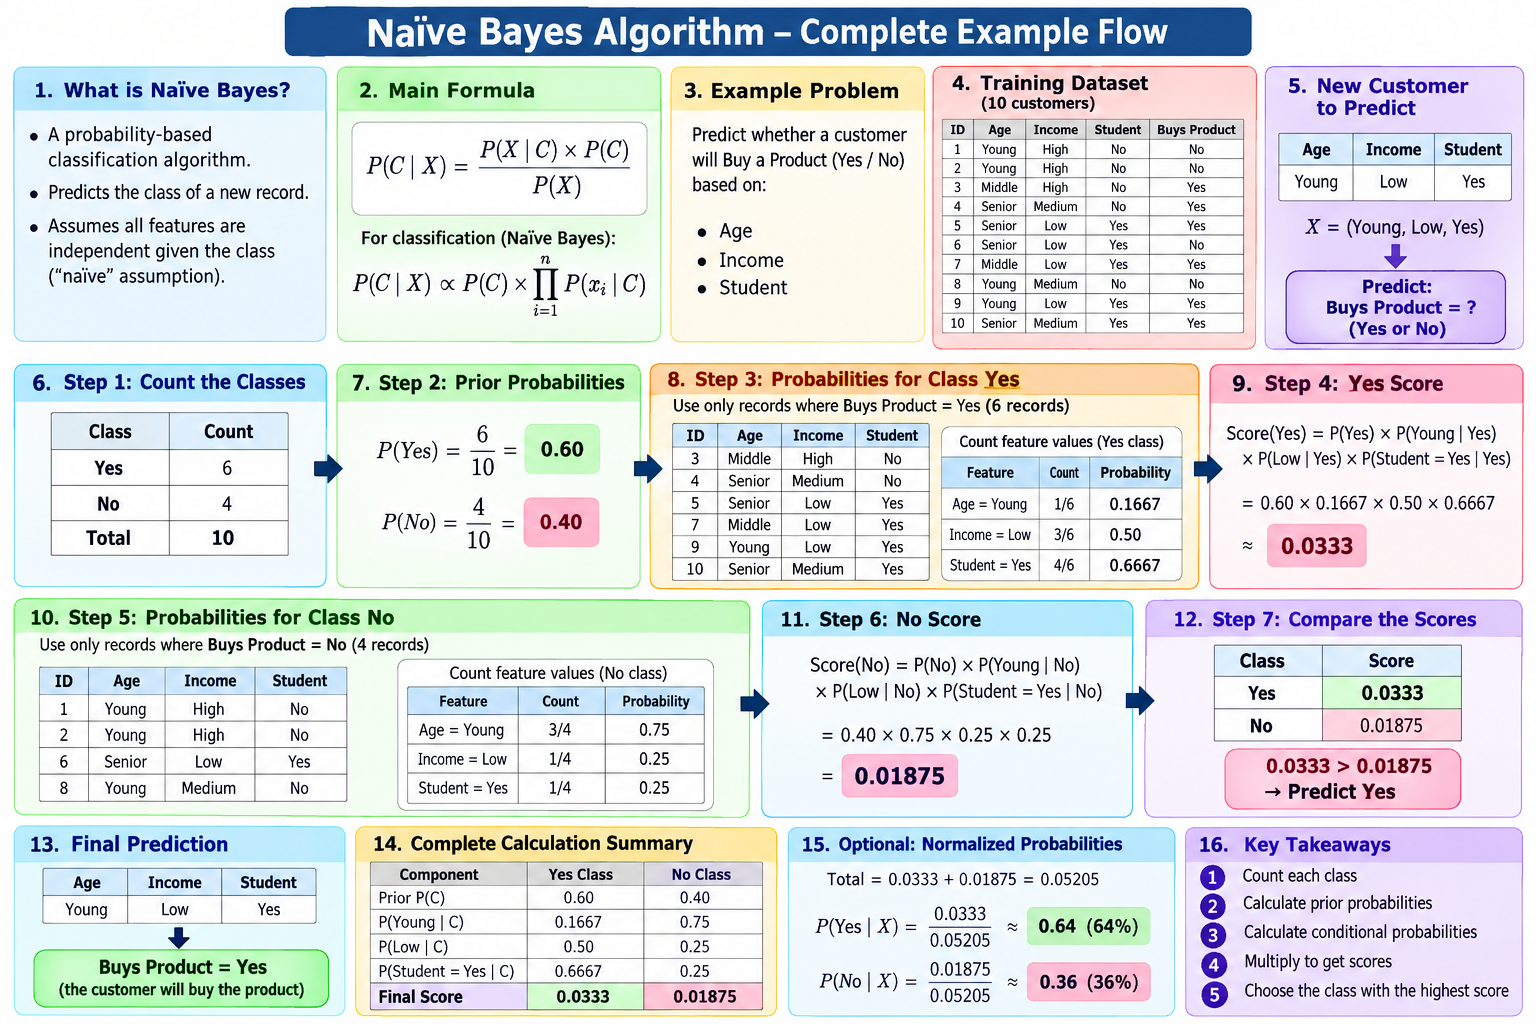

# 📘 Decision Tree Algorithm

---

# 🔹 1. What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm used for **classification** and **regression**.

For classification, it predicts a class by repeatedly asking questions about the input features.

> **Decision Tree = Ask a question → Follow a branch → Ask another question → Reach a prediction**

For example, a business may want to predict:

> **Will a customer buy a product?**

The tree might ask:

```text
                    Student?
                   /        \
                Yes          No
                /             \
             Buy          Income?
                         /       \
                       Low       High
                       /           \
                     Buy         Not Buy
```

Each question divides the data into smaller groups until a prediction can be made.

---

# 🔹 2. Simple Meaning

Imagine making a business decision manually.

Suppose a customer arrives.

You might think:

**Question 1:** Is the customer a student?

- If **Yes** → they may buy the product.
- If **No** → check another characteristic.

**Question 2:** Is their income high?

- If **Yes** → they may not buy.
- If **No** → they may buy.

A Decision Tree learns these questions automatically from historical data.

---

# 🔹 3. Where Can Decision Trees Be Used?

| Application | Example Prediction |
|---|---|
| 🛒 Marketing | Buy / Not Buy |
| 💳 Banking | Loan Approved / Rejected |
| 📉 Finance | High Risk / Low Risk |
| 🎓 Education | Pass / Fail |
| 📧 Marketing | Respond / Not Respond |
| 👥 Customer Analytics | Churn / Stay |
| 🏥 Healthcare | Disease / No Disease |

---

# 🔹 4. Structure of a Decision Tree

A Decision Tree has four important components.

### 🌳 1. Root Node

The **first question** in the tree.

```text
              [Student?]
```

It contains the entire dataset before the first split.

---

### 🌿 2. Decision/Internal Node

A node where another question is asked.

```text
              [Income?]
              /      \
           Low       High
```

---

### 🔀 3. Branch

A branch represents the result of a decision.

```text
Student?
   |
  Yes
   |
   ↓
```

---

### 🍃 4. Leaf Node

The final prediction.

```text
        [BUY = YES]
```

No further question is required.

---

# 🔹 5. How Does a Decision Tree Learn?

The most important question is:

> **Which feature should the tree ask about first?**

Suppose we have three features:

- Age
- Income
- Student

The algorithm must decide whether the first question should be:

```text
Age?
```

or

```text
Income?
```

or

```text
Student?
```

A good feature should separate the classes as clearly as possible.

---

# 🔹 6. The Main Idea: Purity

Suppose a node contains:

```text
10 Customers

6 Yes
4 No
```

The node contains a mixture of two classes.

We call this an **impure node**.

Now imagine a node containing:

```text
5 Customers

5 Yes
0 No
```

This node contains only one class.

It is a **pure node**.

### 🎯 Goal of a Decision Tree

> **Create splits that make the resulting groups as pure as possible.**

---

# 🔹 7. How Do We Measure Purity?

Several methods can be used.

The most common are:

| Method | Commonly Associated With |
|---|---|
| **Entropy** | ID3 / information theory |
| **Information Gain** | ID3 |
| **Gain Ratio** | C4.5 |
| **Gini Impurity** | CART |

For teaching the manual calculation, we will first use:

# ⭐ Entropy + Information Gain

The main process is:

```text
Calculate Entropy
       ↓
Try each feature
       ↓
Calculate Information Gain
       ↓
Choose highest Information Gain
       ↓
Create the split
```

---

# 🔹 8. What is Entropy?

**Entropy measures impurity or uncertainty in the data.**

For a binary classification problem:

$$
\boxed{
H(S)
=
-p_1\log_2(p_1)
-p_2\log_2(p_2)
}
$$

For our Yes/No problem:

$$
\boxed{
H(S)
=
-P(Yes)\log_2P(Yes)
-P(No)\log_2P(No)
}
$$

where:

$$
P(Yes)
=
\frac{\text{Number of Yes}}
{\text{Total Records}}
$$

and:

$$
P(No)
=
\frac{\text{Number of No}}
{\text{Total Records}}
$$

---

# 🔹 9. Understanding Entropy Without Mathematics

Students should first understand what the number means.

### Case 1 — Completely Pure

Suppose:

```text
10 Yes
0 No
```

Then:

$$
H(S)=0
$$

This is perfect purity.

---

### Case 2 — Completely Mixed

Suppose:

```text
5 Yes
5 No
```

Then:

$$
H(S)=1
$$

This represents maximum uncertainty for two classes.

---

### Easy Interpretation

| Entropy | Meaning |
|---:|---|
| **0** | Pure |
| Close to **0** | Mostly pure |
| Close to **1** | Highly mixed |
| **1** | Maximum impurity for two equally likely classes |

So:

> **Lower Entropy = Better Purity**

---

# 🔹 10. What is Information Gain?

Entropy tells us how mixed the data is.

**Information Gain tells us how much a feature reduces that impurity.**

The formula is:

$$
\boxed{
IG(S,A)
=
H(S)
-
H(S \mid A)
}
$$

where:

- $S$ = current dataset
- $A$ = feature being tested
- $H(S)$ = entropy before splitting
- $H(S \mid A)$ = weighted entropy after splitting on feature $A$

In simple words:

$$
\boxed{
\text{Information Gain}
=
\text{Entropy Before}
-
\text{Entropy After}
}
$$

---

# 🔹 11. What Does Information Gain Mean?

Suppose:

```text
Entropy Before Split = 0.97
```

After splitting using **Student**:

```text
Weighted Entropy = 0.60
```

Then:

$$
IG(Student)
=
0.97-0.60
$$

$$
IG(Student)=0.37
$$

So the feature **Student** reduced uncertainty by 0.37.

---

# 🔹 12. Which Feature Do We Choose?

Suppose we calculate:

| Feature | Information Gain |
|---|---:|
| Age | 0.15 |
| Income | 0.08 |
| Student | **0.37** |

We choose:

$$
\boxed{Student}
$$

because:

$$
\boxed{
IG(Student)
>
IG(Age)
>
IG(Income)
}
$$

### 🎯 Rule

> **Higher Information Gain = Better Split**

Therefore:

$$
\boxed{
\text{Choose the feature with the highest Information Gain}
}
$$

---

# 🔹 13. Our Example Dataset

We can use the **same customer dataset as Naïve Bayes** so students can see how two different algorithms solve the same business problem.

### 🎯 Business Problem

Predict whether a customer will **Buy a Product**.

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 1 | Young | High | No | No |
| 2 | Young | High | No | No |
| 3 | Middle | High | No | Yes |
| 4 | Senior | Medium | No | Yes |
| 5 | Senior | Low | Yes | Yes |
| 6 | Senior | Low | Yes | No |
| 7 | Middle | Low | Yes | Yes |
| 8 | Young | Medium | No | No |
| 9 | Young | Low | Yes | Yes |
| 10 | Senior | Medium | Yes | Yes |

Target:

$$
\text{Buys Product} \in \{Yes,No\}
$$

---

# 🔹 14. New Customer

We will eventually use the tree to predict the **same new customer**:

| Age | Income | Student |
|---|---|---|
| Young | Low | Yes |

Therefore:

$$
X=(Young,Low,Yes)
$$

We want to predict:

$$
\boxed{
Buys\ Product=?
}
$$

---

# 🔹 15. STEP 1 — Count the Classes

From our dataset:

```text
Total Customers = 10

Yes = 6
No  = 4
```

Therefore:

$$
P(Yes)=\frac{6}{10}=0.6
$$

and:

$$
P(No)=\frac{4}{10}=0.4
$$

---

# 🔹 16. STEP 2 — Calculate the Entropy of the Dataset

Formula:

$$
H(S)
=
-P(Yes)\log_2P(Yes)
-P(No)\log_2P(No)
$$

Substitute:

$$
H(S)
=
-(0.6)\log_2(0.6)
-
(0.4)\log_2(0.4)
$$

Calculate:

$$
\log_2(0.6)\approx-0.737
$$

and:

$$
\log_2(0.4)\approx-1.322
$$

Therefore:

$$
H(S)
=
-(0.6)(-0.737)
-
(0.4)(-1.322)
$$

$$
H(S)
=
0.4422+0.5288
$$

Therefore:

$$
\boxed{
H(S)\approx0.971
}
$$

---

# 🔹 17. What Does 0.971 Mean?

Our starting entropy is:

$$
\boxed{0.971}
$$

This is quite high.

Why?

Because the dataset contains:

```text
6 Yes
4 No
```

Both classes are strongly represented.

Therefore, the dataset is relatively mixed.

Our goal is now to find a feature that reduces this entropy.

---

# 🔹 18. STEP 3 — Test Each Feature

We have three possible features:

```text
Age
Income
Student
```

We need to calculate:

$$
IG(Age)
$$

$$
IG(Income)
$$

and:

$$
IG(Student)
$$

Then compare them.

---

# 🔹 19. How Do We Calculate Entropy After a Split?

Suppose a feature divides the dataset into several groups.

The entropy after the split is a **weighted average**:

$$
\boxed{
H(S \mid A)
=
\sum_{v \in Values(A)}
\frac{|S_v|}{|S|}
H(S_v)
}
$$

In simple terms:

$$
\boxed{
\text{Weighted Entropy}
=
\sum
\left(
\text{Group Weight}
\times
\text{Group Entropy}
\right)
}
$$

Why do we use weights?

Because groups may contain different numbers of records.

A group containing 6 customers should influence the result more than a group containing only 1 customer.

---

# 🔹 20. Example: Splitting on Student

The feature **Student** has two values:

```text
Student = Yes
Student = No
```

Let's separate the dataset.

### Student = Yes

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 5 | Senior | Low | Yes | Yes |
| 6 | Senior | Low | Yes | No |
| 7 | Middle | Low | Yes | Yes |
| 9 | Young | Low | Yes | Yes |
| 10 | Senior | Medium | Yes | Yes |

Count:

```text
Yes = 4
No  = 1
Total = 5
```

Therefore:

$$
P(Yes)=\frac{4}{5}=0.8
$$

$$
P(No)=\frac{1}{5}=0.2
$$

Entropy:

$$
H(Student=Yes)
=
-(0.8)\log_2(0.8)
-
(0.2)\log_2(0.2)
$$

Therefore:

$$
\boxed{
H(Student=Yes)\approx0.722
}
$$

---

# 🔹 21. Student = No

Now consider customers where:

$$
Student=No
$$

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 1 | Young | High | No | No |
| 2 | Young | High | No | No |
| 3 | Middle | High | No | Yes |
| 4 | Senior | Medium | No | Yes |
| 8 | Young | Medium | No | No |

Count:

```text
Yes = 2
No  = 3
Total = 5
```

Therefore:

$$
P(Yes)=\frac{2}{5}=0.4
$$

$$
P(No)=\frac{3}{5}=0.6
$$

Entropy:

$$
H(Student=No)
=
-(0.4)\log_2(0.4)
-
(0.6)\log_2(0.6)
$$

Therefore:

$$
\boxed{
H(Student=No)\approx0.971
}
$$

---

# 🔹 22. Calculate Weighted Entropy for Student

Both groups contain 5 records.

Therefore:

$$
H(S \mid Student)
=
\frac{5}{10}(0.722)
+
\frac{5}{10}(0.971)
$$

$$
H(S \mid Student)
=
0.361+0.4855
$$

Therefore:

$$
\boxed{
H(S \mid Student)\approx0.8465
}
$$

---

# 🔹 23. Calculate Information Gain for Student

Remember:

$$
IG(S,A)
=
H(S)-H(S \mid A)
$$

Therefore:

$$
IG(Student)
=
0.971-0.8465
$$

$$
\boxed{
IG(Student)\approx0.1245
}
$$

So splitting by **Student** reduces entropy by approximately:

$$
0.1245
$$

---

# 🔹 24. But We Cannot Choose Student Yet

This is extremely important.

We cannot say:

> "Student is the root."

We have only calculated the Information Gain for **one feature**.

We must calculate the same thing for:

$$
Age
$$

and:

$$
Income
$$

Then compare all three:

| Feature | Information Gain |
|---|---:|
| Age | Calculate |
| Income | Calculate |
| Student | 0.1245 |

Only after calculating all features can we choose the root node.

---

# 🔹 25. Complete Decision Tree Learning Process

The algorithm follows this process:

```text
             START
               │
               ▼
      Calculate Parent Entropy
               │
               ▼
        Test Feature: Age
               │
               ▼
       Calculate IG(Age)
               │
               ▼
      Test Feature: Income
               │
               ▼
      Calculate IG(Income)
               │
               ▼
     Test Feature: Student
               │
               ▼
     Calculate IG(Student)
               │
               ▼
       Compare All Gains
               │
               ▼
    Choose Highest Information Gain
               │
               ▼
         Create Root Node
               │
               ▼
       Repeat on Each Branch
               │
               ▼
       Reach Leaf / Prediction
```

---

# 🔹 26. How Does Prediction Work After Training?

Once the complete tree has been created, prediction is much easier.

Suppose the trained tree contains:

```text
                   [Root Feature]
                    /    |    \
                   /     |     \
             Condition Condition Condition
                 │        │        │
                 ▼        ▼        ▼
             Question   Class    Question
                 │                 │
                 ▼                 ▼
               Class             Class
```

For a new customer:

$$
X=(Young,Low,Yes)
$$

we simply follow the appropriate branches until reaching a leaf.

The leaf gives the prediction.

---

# 🔹 27. Decision Tree vs Naïve Bayes

Since we are using the same dataset, students can clearly see the difference.

| Naïve Bayes | Decision Tree |
|---|---|
| Probability based | Rule/tree based |
| Calculates class probabilities | Creates decision rules |
| Uses prior probabilities | Uses recursive splits |
| Uses conditional probabilities | Uses features as decision nodes |
| Assumes conditional independence | Does not require that assumption |
| Predicts highest-scoring class | Follows branches to a leaf |

### Naïve Bayes thinks:

> "Which class has the highest probability?"

### Decision Tree thinks:

> "Which sequence of questions best separates the classes?"

---

# 🔹 28. Gini Impurity

Not every Decision Tree uses Entropy.

Another very common measure is **Gini Impurity**.

For multiple classes:

$$
\boxed{
Gini(S)
=
1-\sum_{i=1}^{k}p_i^2
}
$$

For two classes:

$$
Gini(S)
=
1-
\left[
P(Yes)^2+P(No)^2
\right]
$$

For our dataset:

$$
Gini(S)
=
1-
\left[
(0.6)^2+(0.4)^2
\right]
$$

$$
Gini(S)
=
1-(0.36+0.16)
$$

$$
Gini(S)=1-0.52
$$

Therefore:

$$
\boxed{
Gini(S)=0.48
}
$$

Again:

> **Lower Gini = Purer node**

---

# 🔹 29. Entropy vs Gini

| Entropy | Gini |
|---|---|
| Measures uncertainty | Measures impurity |
| Uses logarithms | Uses squared probabilities |
| Range for binary classes: 0–1 | Range for binary classes: 0–0.5 |
| Used with Information Gain | Commonly used by CART |
| Slightly more computationally involved | Simpler to calculate |

For our manual classroom example, we will continue with:

$$
\boxed{
Entropy + Information\ Gain
}
$$

because it clearly demonstrates **why a feature is selected**.

---

# 🔹 30. When Does a Tree Stop Growing?

A Decision Tree should not keep splitting forever.

It can stop when:

- A node contains only one class.
- No useful features remain.
- A maximum depth is reached.
- Too few samples remain.
- Further splitting provides very little improvement.

For example:

```text
Node:

5 customers
5 Yes
0 No
```

This is already pure.

Therefore:

$$
Entropy=0
$$

There is no need for another split.

The node can become:

```text
🍃 BUY = YES
```

---

# 🔹 31. Overfitting

One major problem with Decision Trees is **overfitting**.

Imagine a very large tree:

```text
Age?
 ↓
Income?
 ↓
Student?
 ↓
Location?
 ↓
Occupation?
 ↓
Previous Purchase?
 ↓
...
```

The tree may become so detailed that it memorizes the training data.

It can then perform poorly on new customers.

This is called:

> **Overfitting**

---

# 🔹 32. How Can We Control Overfitting?

Common parameters include:

| Parameter | Purpose |
|---|---|
| `max_depth` | Maximum depth of tree |
| `min_samples_split` | Minimum samples needed to split |
| `min_samples_leaf` | Minimum samples required in a leaf |
| `max_leaf_nodes` | Maximum number of leaf nodes |
| `ccp_alpha` | Controls cost-complexity pruning |

The basic idea is:

> **Do not allow the tree to become unnecessarily complex.**

---

# 🔹 33. Advantages

| Advantage | Explanation |
|---|---|
| Easy to understand | Tree can be visualized |
| Interpretable | Decisions can be explained |
| Little preprocessing | Scaling is generally unnecessary |
| Numerical + categorical concepts | Can model different feature relationships, though implementations differ in categorical support |
| Non-linear relationships | Can learn complex decision boundaries |
| Feature interactions | Can naturally model interactions through sequential splits |

---

# 🔹 34. Limitations

| Limitation | Explanation |
|---|---|
| Overfitting | Deep trees may memorize training data |
| Instability | Small data changes can produce different trees |
| Greedy splitting | A locally good split may not produce the globally best tree |
| Bias toward some splits | Certain splitting criteria can favor features with many possible split points |
| Complex trees | Large trees become difficult to interpret |

---

# 🔹 35. Main Decision Tree Algorithm

For a classification problem:

### Step 1 — Start with all training data

$$
S
$$

### Step 2 — Measure impurity

For example:

$$
H(S)
$$

### Step 3 — Try each possible feature/split

$$
A_1,A_2,\ldots,A_n
$$

### Step 4 — Calculate the quality of each split

For entropy-based learning:

$$
IG(S,A)
=
H(S)-H(S \mid A)
$$

### Step 5 — Choose the best split

$$
\boxed{
A^*
=
\underset{A}{\operatorname{argmax}}
\ IG(S,A)
}
$$

### Step 6 — Create branches

Split the dataset according to the selected feature.

### Step 7 — Repeat

Apply the same process recursively to the child nodes.

### Step 8 — Stop

Stop when the stopping condition is satisfied.

---

# 🎯 Main Memory Trick

Students can remember Decision Trees using:

## **MEASURE → SPLIT → COMPARE → CHOOSE → REPEAT**

### 1. MEASURE

Calculate current impurity:

$$
Entropy
$$

### 2. SPLIT

Try splitting using each feature.

### 3. COMPARE

Calculate how much each split improves purity:

$$
Information\ Gain
$$

### 4. CHOOSE

Choose the best split:

$$
\boxed{
Highest\ Information\ Gain
}
$$

### 5. REPEAT

Repeat the process for the resulting branches.

---

# 🧠 One-Line Exam Definition

> **A Decision Tree is a supervised machine learning algorithm that recursively splits data based on feature values to create increasingly pure groups and make predictions at leaf nodes.**

---

# ⭐ Most Important Concept

For our entropy-based classroom example:

$$
\boxed{
Information\ Gain
=
Entropy\ Before
-
Weighted\ Entropy\ After
}
$$

and:

$$
\boxed{
Higher\ Information\ Gain
=
Better\ Split
}
$$

So the core idea is:

```text
Mixed Data
    ↓
Calculate Entropy
    ↓
Try Every Feature
    ↓
Calculate Information Gain
    ↓
Choose Highest Gain
    ↓
Split the Data
    ↓
Repeat
    ↓
Reach Pure/Stopping Nodes
    ↓
Make Prediction
```


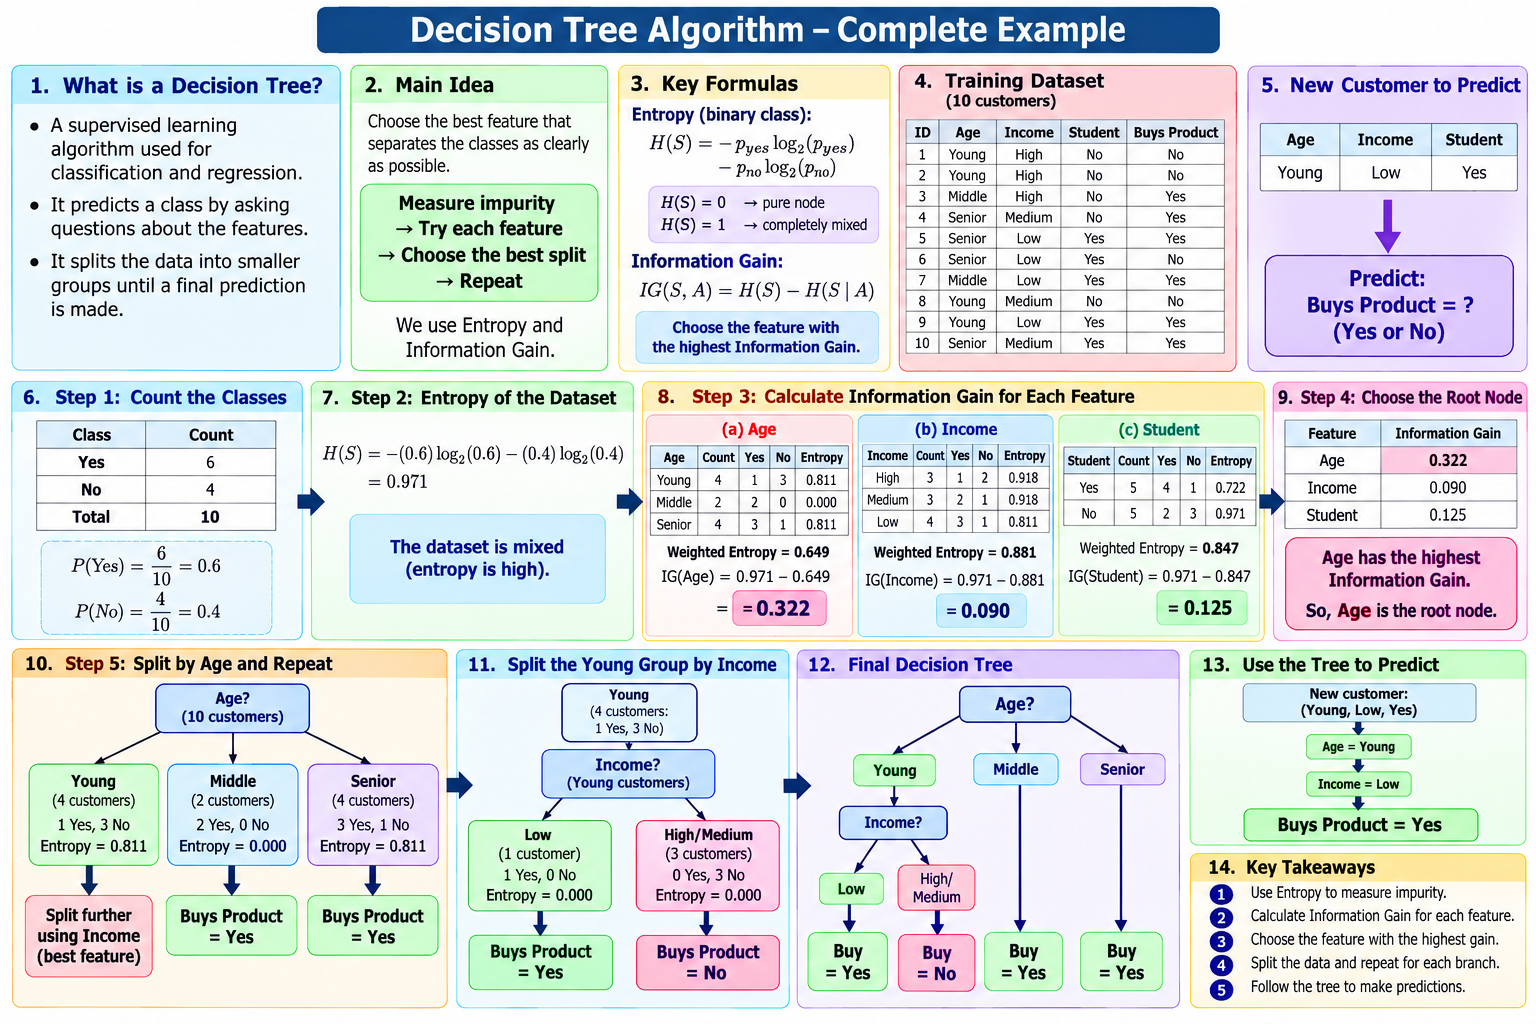



# 📘 K-Nearest Neighbors (KNN) Algorithm

---

# 🔹 1. What is KNN?

**K-Nearest Neighbors (KNN)** is a supervised machine learning algorithm used for:

- **Classification**
- **Regression**

For classification, KNN predicts the class of a new observation by looking at the classes of its **nearest existing observations**.

> **KNN = Find the nearest neighbors → Check their classes → Let them vote**

---

# 🔹 2. Simple Meaning

Imagine a new customer enters a store.

We do not know whether the customer will:

- **Buy**
- **Not Buy**

Instead of creating a complex formula, KNN asks:

> **“Which existing customers are most similar to this new customer?”**

If most nearby customers bought the product, KNN predicts:

$$
\boxed{Buy=Yes}
$$

If most nearby customers did not buy the product:

$$
\boxed{Buy=No}
$$

---

# 🔹 3. Why is it Called K-Nearest Neighbors?

The name has three important parts:

### **K**

The number of neighbors we want to examine.

For example:

$$
K=3
$$

means:

> Look at the **3 nearest observations**.

### **Nearest**

We calculate how close observations are using a **distance measure**.

### **Neighbors**

The observations closest to the new observation are called its **neighbors**.

Therefore:

$$
\boxed{
KNN = K\ Nearest\ Neighbors
}
$$

---

# 🔹 4. Basic Idea

Suppose:

$$
K=3
$$

The three nearest customers to a new customer are:

| Neighbor | Class |
|---|---|
| Customer A | Yes |
| Customer B | Yes |
| Customer C | No |

Count the votes:

$$
Yes=2
$$

$$
No=1
$$

Since:

$$
2>1
$$

KNN predicts:

$$
\boxed{Yes}
$$

---

# 🔹 5. KNN Does Not Learn a Traditional Model

This is an important characteristic of KNN.

Algorithms such as Decision Trees create a model during training.

KNN mainly **stores the training data**.

When a new observation arrives, it calculates its distance from the stored observations.

For this reason, KNN is often described as:

> **Lazy Learning**

Training is very simple, but prediction can require many distance calculations.

---

# 🔹 6. Main Steps of KNN

KNN classification follows these steps:

### Step 1 — Choose \(K\)

Example:

$$
K=3
$$

### Step 2 — Calculate distance

Calculate the distance between the new observation and every training observation.

### Step 3 — Sort distances

Arrange observations from:

$$
Smallest\ Distance
\rightarrow
Largest\ Distance
$$

### Step 4 — Select nearest neighbors

Choose the first \(K\) observations.

### Step 5 — Count their classes

For example:

$$
Yes=2,\qquad No=1
$$

### Step 6 — Majority vote

Choose the most common class.

$$
\boxed{Prediction=Yes}
$$

---

# 🔹 7. How Does KNN Measure Distance?

The most common distance measure is:

# ⭐ Euclidean Distance

For two features:

$$
\boxed{
d=
\sqrt{
(x_1-y_1)^2+
(x_2-y_2)^2
}
}
$$

For \(n\) features:

$$
\boxed{
d(\mathbf{x},\mathbf{y})
=
\sqrt{
\sum_{i=1}^{n}(x_i-y_i)^2
}
}
$$

---

# 🔹 8. Understanding Euclidean Distance

Suppose we have two customers:

$$
A=(2,3)
$$

and:

$$
B=(5,7)
$$

Their distance is:

$$
d(A,B)
=
\sqrt{
(2-5)^2+
(3-7)^2
}
$$

Calculate:

$$
d(A,B)
=
\sqrt{
(-3)^2+
(-4)^2
}
$$

$$
d(A,B)
=
\sqrt{
9+16
}
$$

$$
d(A,B)
=
\sqrt{25}
$$

Therefore:

$$
\boxed{
d(A,B)=5
}
$$

---

# 🔹 9. What Does Distance Mean?

Distance tells us how similar two observations are in feature space.

### Small Distance

$$
\boxed{Small\ Distance=More\ Similar}
$$

### Large Distance

$$
\boxed{Large\ Distance=Less\ Similar}
$$

For example:

| Customer | Distance |
|---|---:|
| A | 1.2 |
| B | 4.8 |
| C | 0.7 |

The closest customer is:

$$
\boxed{Customer\ C}
$$

because:

$$
0.7<1.2<4.8
$$

---

# 🔹 10. Complete Business Example

## 🎯 Problem

A business wants to predict whether a new customer will **Buy a Product**.

For a clear manual KNN example, we will use two **numerical features**:

- **Age**
- **Income**

Target:

$$
Buy\ Product\in\{Yes,No\}
$$

Our training data is:

| Customer | Age | Income (000s) | Buys Product |
|---|---:|---:|---|
| C1 | 22 | 25 | No |
| C2 | 25 | 30 | No |
| C3 | 28 | 35 | No |
| C4 | 32 | 45 | Yes |
| C5 | 35 | 50 | Yes |
| C6 | 40 | 55 | Yes |
| C7 | 45 | 60 | Yes |
| C8 | 48 | 65 | Yes |

---

# 🔹 11. New Customer to Predict

A new customer has:

| Age | Income (000s) |
|---:|---:|
| 33 | 48 |

Therefore:

$$
\boxed{
X=(33,48)
}
$$

We want to predict:

$$
\boxed{
Buy\ Product=?
}
$$

We will use:

$$
\boxed{K=3}
$$

So we need to find the **3 nearest customers**.

---

# 🔹 12. STEP 1 — Choose K

We choose:

$$
\boxed{K=3}
$$

This means:

> Find the **three training customers closest to the new customer**.

Then let those three customers vote.

---

# 🔹 13. STEP 2 — Distance from Customer C1

New customer:

$$
X=(33,48)
$$

Customer C1:

$$
C_1=(22,25)
$$

Use Euclidean distance:

$$
d(X,C_1)
=
\sqrt{
(33-22)^2+
(48-25)^2
}
$$

$$
=
\sqrt{
11^2+23^2
}
$$

$$
=
\sqrt{
121+529
}
$$

$$
=
\sqrt{650}
$$

Therefore:

$$
\boxed{
d(X,C_1)\approx25.50
}
$$

Class:

$$
No
$$

---

# 🔹 14. STEP 3 — Distance from Customer C2

Customer C2:

$$
C_2=(25,30)
$$

Calculate:

$$
d(X,C_2)
=
\sqrt{
(33-25)^2+
(48-30)^2
}
$$

$$
=
\sqrt{
8^2+18^2
}
$$

$$
=
\sqrt{
64+324
}
$$

$$
=
\sqrt{388}
$$

Therefore:

$$
\boxed{
d(X,C_2)\approx19.70
}
$$

Class:

$$
No
$$

---

# 🔹 15. STEP 4 — Distance from Customer C3

Customer C3:

$$
C_3=(28,35)
$$

$$
d(X,C_3)
=
\sqrt{
(33-28)^2+
(48-35)^2
}
$$

$$
=
\sqrt{
5^2+13^2
}
$$

$$
=
\sqrt{
25+169
}
$$

$$
=
\sqrt{194}
$$

Therefore:

$$
\boxed{
d(X,C_3)\approx13.93
}
$$

Class:

$$
No
$$

---

# 🔹 16. STEP 5 — Distance from Customer C4

Customer C4:

$$
C_4=(32,45)
$$

$$
d(X,C_4)
=
\sqrt{
(33-32)^2+
(48-45)^2
}
$$

$$
=
\sqrt{
1^2+3^2
}
$$

$$
=
\sqrt{
1+9
}
$$

$$
=
\sqrt{10}
$$

Therefore:

$$
\boxed{
d(X,C_4)\approx3.16
}
$$

Class:

$$
Yes
$$

---

# 🔹 17. STEP 6 — Distance from Customer C5

Customer C5:

$$
C_5=(35,50)
$$

$$
d(X,C_5)
=
\sqrt{
(33-35)^2+
(48-50)^2
}
$$

$$
=
\sqrt{
(-2)^2+(-2)^2
}
$$

$$
=
\sqrt{
4+4
}
$$

$$
=
\sqrt{8}
$$

Therefore:

$$
\boxed{
d(X,C_5)\approx2.83
}
$$

Class:

$$
Yes
$$

---

# 🔹 18. STEP 7 — Distance from Customer C6

Customer C6:

$$
C_6=(40,55)
$$

$$
d(X,C_6)
=
\sqrt{
(33-40)^2+
(48-55)^2
}
$$

$$
=
\sqrt{
(-7)^2+(-7)^2
}
$$

$$
=
\sqrt{
49+49
}
$$

$$
=
\sqrt{98}
$$

Therefore:

$$
\boxed{
d(X,C_6)\approx9.90
}
$$

Class:

$$
Yes
$$

---

# 🔹 19. STEP 8 — Distance from Customer C7

Customer C7:

$$
C_7=(45,60)
$$

$$
d(X,C_7)
=
\sqrt{
(33-45)^2+
(48-60)^2
}
$$

$$
=
\sqrt{
(-12)^2+(-12)^2
}
$$

$$
=
\sqrt{
144+144
}
$$

$$
=
\sqrt{288}
$$

Therefore:

$$
\boxed{
d(X,C_7)\approx16.97
}
$$

Class:

$$
Yes
$$

---

# 🔹 20. STEP 9 — Distance from Customer C8

Customer C8:

$$
C_8=(48,65)
$$

$$
d(X,C_8)
=
\sqrt{
(33-48)^2+
(48-65)^2
}
$$

$$
=
\sqrt{
(-15)^2+(-17)^2
}
$$

$$
=
\sqrt{
225+289
}
$$

$$
=
\sqrt{514}
$$

Therefore:

$$
\boxed{
d(X,C_8)\approx22.67
}
$$

Class:

$$
Yes
$$

---

# 🔹 21. STEP 10 — Put All Distances Together

We now have:

| Customer | Age | Income | Class | Distance from New Customer |
|---|---:|---:|---|---:|
| C1 | 22 | 25 | No | 25.50 |
| C2 | 25 | 30 | No | 19.70 |
| C3 | 28 | 35 | No | 13.93 |
| C4 | 32 | 45 | Yes | **3.16** |
| C5 | 35 | 50 | Yes | **2.83** |
| C6 | 40 | 55 | Yes | **9.90** |
| C7 | 45 | 60 | Yes | 16.97 |
| C8 | 48 | 65 | Yes | 22.67 |

But we are not finished.

KNN needs the **nearest** observations.

So we sort the table.

---

# 🔹 22. STEP 11 — Sort by Distance

Arrange the customers from smallest distance to largest:

| Rank | Customer | Distance | Class |
|---:|---|---:|---|
| 🥇 1 | C5 | **2.83** | Yes |
| 🥈 2 | C4 | **3.16** | Yes |
| 🥉 3 | C6 | **9.90** | Yes |
| 4 | C3 | 13.93 | No |
| 5 | C7 | 16.97 | Yes |
| 6 | C2 | 19.70 | No |
| 7 | C8 | 22.67 | Yes |
| 8 | C1 | 25.50 | No |

---

# 🔹 23. STEP 12 — Select the K Nearest Neighbors

We selected:

$$
K=3
$$

Therefore, only take the first **3 nearest customers**:

| Neighbor | Customer | Distance | Class |
|---:|---|---:|---|
| 1 | C5 | 2.83 | **Yes** |
| 2 | C4 | 3.16 | **Yes** |
| 3 | C6 | 9.90 | **Yes** |

Ignore the remaining customers for this vote.

---

# 🔹 24. STEP 13 — Majority Voting

Count the classes among the 3 nearest neighbors.

### Yes Votes

$$
Yes=3
$$

### No Votes

$$
No=0
$$

Therefore:

$$
3>0
$$

So:

$$
\boxed{
Prediction=Yes
}
$$

---

# ✅ 25. Final Prediction

The new customer is:

$$
X=(33,48)
$$

The three nearest neighbors are:

$$
C_5,\ C_4,\ C_6
$$

Their classes are:

$$
Yes,\ Yes,\ Yes
$$

Therefore:

$$
\boxed{
Buy\ Product=Yes
}
$$

### 💡 Interpretation

The new customer is located closest to customers who previously **bought the product**.

Therefore, KNN classifies the new customer as:

> **Likely to buy the product.**

---

# 🔹 26. Complete Calculation at a Glance

### New Customer

$$
\boxed{
X=(33,48)
}
$$

### Choose K

$$
\boxed{
K=3
}
$$

### Calculate Distances

$$
\begin{aligned}
d(C_1)&=25.50\\
d(C_2)&=19.70\\
d(C_3)&=13.93\\
d(C_4)&=3.16\\
d(C_5)&=2.83\\
d(C_6)&=9.90\\
d(C_7)&=16.97\\
d(C_8)&=22.67
\end{aligned}
$$

### Three Smallest Distances

$$
\boxed{
2.83,\ 3.16,\ 9.90
}
$$

Corresponding classes:

$$
\boxed{
Yes,\ Yes,\ Yes
}
$$

### Majority Vote

$$
Yes=3
$$

$$
No=0
$$

### Prediction

$$
\boxed{
Prediction=Yes
}
$$

---

# 🔹 27. Visual Flow of the Example

```text
New Customer
Age = 33
Income = 48
      ↓
Choose K = 3
      ↓
Calculate Distance
from Every Customer
      ↓
Sort Distances
Smallest → Largest
      ↓
Select 3 Nearest
      ↓
C5 → Yes
C4 → Yes
C6 → Yes
      ↓
Count Votes
      ↓
Yes = 3
No  = 0
      ↓
Majority = Yes
      ↓
BUY PRODUCT = YES
```

---

# 🔹 28. What Happens if K = 1?

Suppose:

$$
K=1
$$

Then KNN only looks at the **single nearest customer**.

Our nearest customer is:

$$
C_5
$$

with distance:

$$
2.83
$$

and class:

$$
Yes
$$

Therefore:

$$
\boxed{
Prediction=Yes
}
$$

But using only one neighbor can make the model sensitive to noise or unusual observations.

---

# 🔹 29. What Happens if K is Larger?

Suppose:

$$
K=5
$$

The five nearest neighbors are:

| Rank | Customer | Class |
|---:|---|---|
| 1 | C5 | Yes |
| 2 | C4 | Yes |
| 3 | C6 | Yes |
| 4 | C3 | No |
| 5 | C7 | Yes |

Votes:

$$
Yes=4
$$

$$
No=1
$$

Therefore:

$$
\boxed{
Prediction=Yes
}
$$

The prediction remains Yes in this example.

---

# 🔹 30. How Do We Choose K?

Choosing \(K\) is important.

### Very Small K

For example:

$$
K=1
$$

Advantages:

- Very sensitive to local patterns.

Problem:

- Can be strongly affected by noise.
- Can overfit.

### Larger K

A larger value uses more neighbors.

Advantages:

- Usually smoother and less sensitive to individual noisy observations.

Problem:

- If \(K\) becomes too large, local patterns can be lost.
- The model can underfit.

---

# 🔹 31. Why Do We Often Use Odd K for Two Classes?

Suppose:

$$
K=4
$$

The vote could become:

$$
Yes=2
$$

$$
No=2
$$

That creates a tie.

For binary classification, using an odd value such as:

$$
K=3
$$

or:

$$
K=5
$$

often helps reduce the chance of a tied vote.

It does **not guarantee** that every possible tie disappears, especially with more than two classes or special weighting rules.

---

# 🔹 32. Very Important: Feature Scaling

KNN depends heavily on **distance**.

Consider two features:

| Feature | Typical Range |
|---|---:|
| Age | 18–70 |
| Annual Income | 20,000–2,000,000 |

Income has a much larger numerical scale.

Therefore, income could dominate the distance calculation even if it is not more important.

This is why scaling is very important for KNN.

---

# 🔹 33. Min-Max Normalization

One scaling method is:

$$
\boxed{
x'
=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}
}
$$

This typically transforms values into:

$$
0\leq x'\leq1
$$

For example, age and income can both be placed approximately on the same numerical scale.

---

# 🔹 34. Standardization

Another common method is **Standardization**:

$$
\boxed{
z=
\frac{x-\mu}{\sigma}
}
$$

where:

- \(x\) = original value
- \(\mu\) = mean
- \(\sigma\) = standard deviation

The transformed feature is measured relative to its mean and standard deviation.

### ⭐ Important Rule

> **Scale distance-based features before using KNN when their scales differ meaningfully.**

For our small manual example, the raw values are intentionally kept simple so students can focus on understanding the distance calculation. In a real machine-learning workflow, we would normally evaluate appropriate scaling first.

---

# 🔹 35. Other Distance Measures

Euclidean distance is not the only option.

### Manhattan Distance

$$
\boxed{
d(\mathbf{x},\mathbf{y})
=
\sum_{i=1}^{n}
|x_i-y_i|
}
$$

For two dimensions:

$$
d=
|x_1-y_1|
+
|x_2-y_2|
$$

### Minkowski Distance

$$
\boxed{
d(\mathbf{x},\mathbf{y})
=
\left(
\sum_{i=1}^{n}
|x_i-y_i|^p
\right)^{1/p}
}
$$

When:

$$
p=1
$$

we get Manhattan distance.

When:

$$
p=2
$$

we get Euclidean distance.

---

# 🔹 36. Weighted KNN

Basic KNN gives every selected neighbor an equal vote.

For example:

$$
Yes,\ Yes,\ No
$$

means:

$$
Yes=2,\qquad No=1
$$

But sometimes the **closest neighbor should have more influence**.

Weighted KNN can assign a weight such as:

$$
\boxed{
w_i=\frac{1}{d_i}
}
$$

where:

- \(w_i\) = weight of neighbor \(i\)
- \(d_i\) = distance to neighbor \(i\)

Therefore:

> **Closer neighbor → Larger weight**

Care must be taken when distance is zero because \(1/d_i\) would be undefined; implementations handle exact matches separately.

---

# 🔹 37. KNN for Regression

KNN can also predict a **number** instead of a class.

Suppose the three nearest houses have prices:

$$
200,\ 220,\ 250
$$

A simple KNN regression prediction is their average:

$$
Prediction
=
\frac{200+220+250}{3}
$$

$$
=
\frac{670}{3}
$$

Therefore:

$$
\boxed{
Prediction\approx223.33
}
$$

So:

### Classification

Use:

$$
\boxed{Majority\ Vote}
$$

### Regression

Commonly use:

$$
\boxed{Average\ of\ Neighbor\ Values}
$$

---

# 🔹 38. Advantages of KNN

| Advantage | Explanation |
|---|---|
| **Simple** | Easy to understand |
| **No complex training** | Mainly stores training observations |
| **Flexible** | Works for classification and regression |
| **Non-linear** | Can model complicated class boundaries |
| **Multi-class** | Can naturally handle several classes |

---

# 🔹 39. Limitations of KNN

| Limitation | Explanation |
|---|---|
| **Slow prediction** | Distances may need to be calculated against many training observations |
| **Memory usage** | Training data must generally be retained |
| **Sensitive to scaling** | Large-scale features can dominate distance |
| **Sensitive to K** | Different K values can produce different predictions |
| **Curse of dimensionality** | Distance becomes less informative with many features |
| **Noise sensitivity** | Small K values can be affected by noisy observations |

---

# 🔹 40. KNN vs Decision Tree vs Naïve Bayes

| Naïve Bayes | Decision Tree | KNN |
|---|---|---|
| Probability-based | Rule/split-based | Distance-based |
| Uses priors and likelihoods | Uses recursive splits | Uses nearest observations |
| Makes independence assumption | Builds decision rules | Uses similarity |
| Training is usually fast | Learns a tree | Minimal explicit training |
| Predicts highest probability/score | Follows tree to leaf | Uses neighbor voting |

### Easy distinction

**Naïve Bayes asks:**

> Which class is most probable?

**Decision Tree asks:**

> Which sequence of feature-based decisions leads to a class?

**KNN asks:**

> Which known observations are closest to this new observation?

---

# 🔹 41. Complete KNN Algorithm

Given a new observation:

$$
X=(x_1,x_2,\ldots,x_n)
$$

### Step 1

Choose:

$$
K
$$

### Step 2

Calculate the distance from \(X\) to every training observation:

$$
d(X,X_i)
$$

### Step 3

Sort observations by distance:

$$
Smallest
\rightarrow
Largest
$$

### Step 4

Select the first:

$$
K
$$

neighbors.

### Step 5

For classification, count their classes.

### Step 6

Choose the class with the largest vote:

$$
\boxed{
\hat{y}
=
\operatorname{mode}
\left(
y_{(1)},y_{(2)},\ldots,y_{(K)}
\right)
}
$$

where \(y_{(1)},\ldots,y_{(K)}\) are the labels of the selected nearest neighbors.

---

# 🎯 Main Memory Trick

Remember KNN using:

# **CHOOSE → CALCULATE → SORT → SELECT → VOTE**

### 1. CHOOSE

Choose:

$$
K
$$

### 2. CALCULATE

Calculate distances:

$$
d(X,X_i)
$$

### 3. SORT

Sort:

$$
Smallest\ Distance
\rightarrow
Largest\ Distance
$$

### 4. SELECT

Select:

$$
K\ Nearest\ Neighbors
$$

### 5. VOTE

Count their classes and choose the majority.

---

# ⭐ Complete Example in One View

### New Customer

$$
X=(33,48)
$$

### Choose

$$
K=3
$$

### Nearest Neighbors

$$
C_5=2.83\rightarrow Yes
$$

$$
C_4=3.16\rightarrow Yes
$$

$$
C_6=9.90\rightarrow Yes
$$

### Voting

$$
Yes=3
$$

$$
No=0
$$

Therefore:

$$
\boxed{
Buy\ Product=Yes
}
$$

---

# 🧠 One-Line Exam Definition

> **K-Nearest Neighbors (KNN) is a supervised learning algorithm that predicts a new observation using the classes or values of its K nearest training observations according to a distance measure.**

---

# 🚀 Final Student Shortcut

```text
New Data Point
      ↓
Choose K
      ↓
Calculate Distances
      ↓
Sort Distances
      ↓
Take K Nearest
      ↓
Majority Vote
      ↓
Prediction
```

For our example:

$$
\boxed{
(33,48)
\rightarrow
K=3
\rightarrow
Yes,\ Yes,\ Yes
\rightarrow
Buy=Yes
}
$$

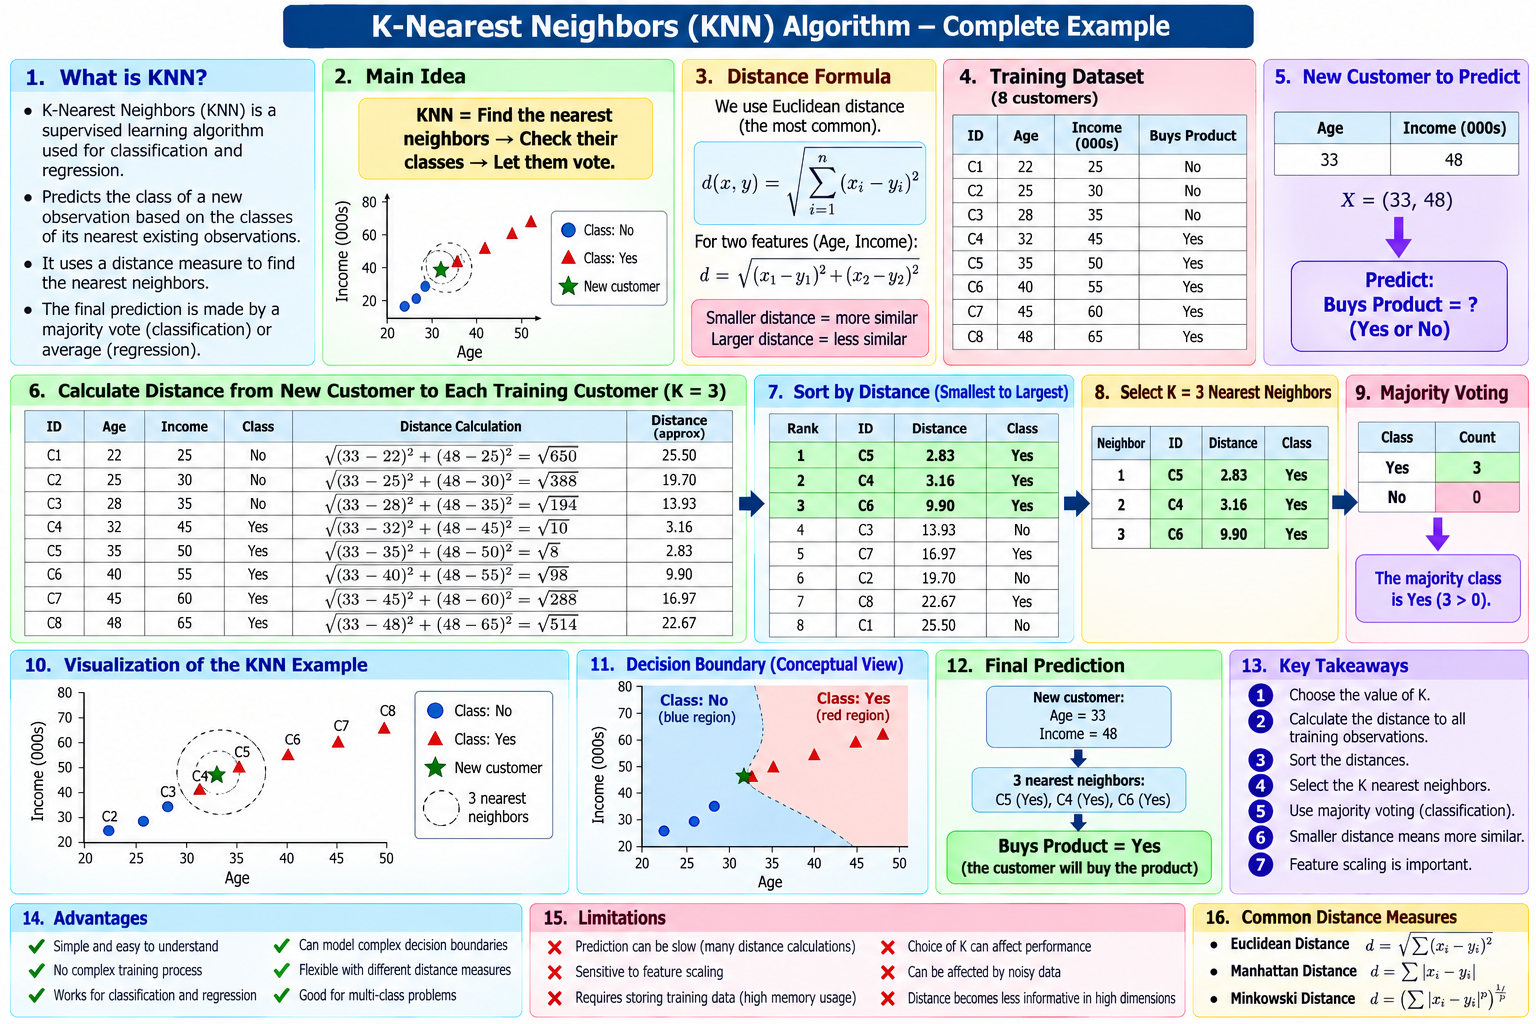

# 📘 WEKA Tutorial: Naïve Bayes, Decision Tree & KNN

This tutorial uses **one common dataset** so students can compare all three algorithms in WEKA using the same workflow.

The three algorithms are:

1. **Naïve Bayes**
2. **Decision Tree — J48**
3. **K-Nearest Neighbors — IBk**

---

# 🔹 1. What is WEKA?

**WEKA (Waikato Environment for Knowledge Analysis)** is a graphical machine-learning tool developed at the University of Waikato.

It allows us to perform machine-learning tasks without writing Python code.

We can:

- Load datasets
- Preprocess data
- Train classifiers
- Test models
- View accuracy
- Examine confusion matrices
- Compare algorithms
- Visualize Decision Trees
- Make predictions

For this tutorial, we will mainly use:

> **WEKA Explorer → Classify**

---

# 🔹 2. Dataset for the Tutorial

We will predict whether a customer will **buy a product**.

### Target Variable

```text
Buys_Product
```

Possible classes:

```text
Yes
No
```

### Features

- Age
- Income
- Student

Use this dataset:

| ID | Age | Income | Student | Buys Product |
|---:|---|---|---|---|
| 1 | Young | High | No | No |
| 2 | Young | High | No | No |
| 3 | Middle | High | No | Yes |
| 4 | Senior | Medium | No | Yes |
| 5 | Senior | Low | Yes | Yes |
| 6 | Senior | Low | Yes | No |
| 7 | Middle | Low | Yes | Yes |
| 8 | Young | Medium | No | No |
| 9 | Young | Low | Yes | Yes |
| 10 | Senior | Medium | Yes | Yes |

---

# 🔹 3. Create the Dataset in ARFF Format

WEKA commonly uses:

$$
\boxed{ARFF}
$$

which stands for:

> **Attribute-Relation File Format**

Create a file named:

```text
customer_buying.arff
```

Paste:

```text
@relation customer_buying

@attribute Age {Young,Middle,Senior}
@attribute Income {High,Medium,Low}
@attribute Student {Yes,No}
@attribute Buys_Product {Yes,No}

@data
Young,High,No,No
Young,High,No,No
Middle,High,No,Yes
Senior,Medium,No,Yes
Senior,Low,Yes,Yes
Senior,Low,Yes,No
Middle,Low,Yes,Yes
Young,Medium,No,No
Young,Low,Yes,Yes
Senior,Medium,Yes,Yes
```

### Important

We do **not** need the ID column.

Why?

Because:

```text
ID = 1, 2, 3, ...
```

is only an identifier. It does not describe customer behavior and should not be used as a predictive feature.

---

# 🔹 4. Open WEKA

Start WEKA.

The **WEKA GUI Chooser** will appear.

You will see options such as:

```text
Explorer
Experimenter
KnowledgeFlow
Workbench
Simple CLI
```

Click:

# ✅ Explorer

---

# 🔹 5. WEKA Explorer

WEKA Explorer contains several tabs:

| Tab | Purpose |
|---|---|
| **Preprocess** | Load and prepare data |
| **Classify** | Classification algorithms |
| **Cluster** | Clustering |
| **Associate** | Association rules |
| **Select attributes** | Feature selection |
| **Visualize** | Data visualization |

For our tutorial, we mainly need:

```text
Preprocess → Classify
```

---

# 🔹 6. Load the Dataset

Inside **Preprocess**, click:

> **Open file...**

Select:

```text
customer_buying.arff
```

WEKA will load the dataset.

You should see approximately:

```text
Relation: customer_buying

Instances: 10
Attributes: 4
```

The attributes should be:

```text
Age
Income
Student
Buys_Product
```

---

# 🔹 7. Explore the Dataset

Click each attribute on the left.

For example, select:

```text
Age
```

WEKA will display information about the attribute.

Try:

```text
Age
Income
Student
Buys_Product
```

This lets students inspect:

- Possible values
- Frequency
- Distribution
- Missing values

---

# 🔹 8. Set the Target/Class Attribute

This step is extremely important.

We want to predict:

```text
Buys_Product
```

At the bottom-right of the Explorer window, find:

> **Class**

Select:

```text
Buys_Product
```

Since it is the final attribute, WEKA will often already display:

```text
Class: Buys_Product
```

Our machine-learning problem is now:

$$
\boxed{
Age + Income + Student
\rightarrow
Buys\ Product
}
$$

---

# 🔹 9. Understanding the Class Distribution

Our dataset contains:

$$
10
$$

customers.

The target distribution is:

$$
Yes=6
$$

$$
No=4
$$

Therefore:

$$
P(Yes)=\frac{6}{10}=0.60
$$

and:

$$
P(No)=\frac{4}{10}=0.40
$$

This is exactly the dataset students used in the manual Naïve Bayes and Decision Tree examples.

---

# 🟦 PART A — NAÏVE BAYES

# 🔹 10. Open the Classify Tab

Click:

> **Classify**

At the top, find:

> **Classifier**

Click:

> **Choose**

Navigate to:

```text
bayes
    ↓
NaiveBayes
```

Select:

# ✅ NaiveBayes

You should see something similar to:

```text
weka.classifiers.bayes.NaiveBayes
```

---

# 🔹 11. Select the Testing Method

WEKA provides several testing options.

You may see:

```text
Use training set
Supplied test set
Cross-validation
Percentage split
```

For a proper introductory evaluation, select:

# ✅ Cross-validation

Set:

```text
Folds = 10
```

So:

$$
\boxed{10\text{-fold Cross-Validation}}
$$

### What does this mean?

WEKA divides the data into approximately 10 parts.

It repeatedly:

```text
Train on most parts
        ↓
Test on the remaining part
        ↓
Repeat
        ↓
Combine results
```

With only 10 records, this is mainly a **teaching demonstration**. Accuracy from such a tiny dataset is not a reliable estimate of real-world performance.

---

# 🔹 12. Run Naïve Bayes

Click:

# ▶ Start

WEKA will train and evaluate the classifier.

The output will appear in:

> **Classifier output**

---

# 🔹 13. Read the Naïve Bayes Output

The output contains several sections.

Look for:

```text
=== Classifier model ===
```

and:

```text
=== Stratified cross-validation ===
```

You may also see:

```text
Correctly Classified Instances
Incorrectly Classified Instances
Kappa statistic
Mean absolute error
Root mean squared error
```

Followed by:

```text
=== Detailed Accuracy By Class ===
```

and:

```text
=== Confusion Matrix ===
```

---

# 🔹 14. Correctly Classified Instances

Suppose WEKA reports:

```text
Correctly Classified Instances   X   XX%
```

This is the number and percentage of test instances classified correctly during the selected evaluation.

The basic accuracy formula is:

$$
\boxed{
Accuracy=
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
\times100
}
$$

Do not manually type an expected percentage into your report. Record the value produced by **your WEKA run**.

---

# 🔹 15. Confusion Matrix

For a two-class problem, a confusion matrix summarizes actual versus predicted classes.

Conceptually:

| | Predicted Yes | Predicted No |
|---|---:|---:|
| **Actual Yes** | Correct Yes | Incorrect No |
| **Actual No** | Incorrect Yes | Correct No |

WEKA may display something like:

```text
 a b   <-- classified as

 ? ? | a = Yes
 ? ? | b = No
```

Students should read the class labels shown by WEKA before interpreting the cells.

---

# 🔹 16. Naïve Bayes Connection to Our Manual Example

Earlier, we manually calculated:

$$
Score(Yes)
=
P(Yes)
P(Young|Yes)
P(Low|Yes)
P(Student=Yes|Yes)
$$

and:

$$
Score(No)
=
P(No)
P(Young|No)
P(Low|No)
P(Student=Yes|No)
$$

WEKA performs the corresponding probabilistic calculations automatically, subject to the classifier's implementation and settings.

So instead of manually counting every probability, we simply selected:

```text
Choose
 ↓
bayes
 ↓
NaiveBayes
 ↓
Start
```

---

# 🟩 PART B — DECISION TREE

# 🔹 17. Select J48

Stay inside:

> **Classify**

Click:

> **Choose**

Navigate to:

```text
trees
   ↓
J48
```

Select:

# ✅ J48

You should see:

```text
weka.classifiers.trees.J48
```

J48 is WEKA's implementation of a **C4.5-style decision-tree learner**.

---

# 🔹 18. Keep the Same Evaluation Method

For comparison, keep:

```text
Cross-validation
```

and:

```text
Folds = 10
```

This is important.

If we evaluate Naïve Bayes using one method and J48 using another, their reported results are not directly comparable.

So use the same evaluation setup for all three algorithms.

---

# 🔹 19. Run J48

Click:

# ▶ Start

WEKA will construct and evaluate the Decision Tree.

---

# 🔹 20. Read the Decision Tree

Find:

```text
=== Classifier model (full training set) ===
```

WEKA may show a textual tree such as:

```text
Age = Young
|   ...
Age = Middle: Yes
Age = Senior
|   ...
```

The exact tree depends on the dataset and J48 settings.

Read it from top to bottom.

The first split shown is the **root**.

Indented lines represent deeper branches.

A final class such as:

```text
: Yes
```

represents a leaf prediction.

---

# 🔹 21. Visualize the Decision Tree

One of the most useful features of WEKA is graphical tree visualization.

After J48 finishes:

1. Look at the **Result list** on the left.
2. Find the J48 result.
3. **Right-click** the J48 result.
4. Select:

> **Visualize tree**

A graphical Decision Tree will open.

Students can now visually identify:

```text
Root
 ↓
Branches
 ↓
Internal Nodes
 ↓
Leaf Nodes
```

---

# 🔹 22. Connect J48 to the Manual Calculation

In the manual lesson, we learned that a tree seeks useful splits that reduce impurity.

For entropy-based reasoning:

$$
H(S)
=
-\sum_i p_i\log_2(p_i)
$$

and:

$$
IG(S,A)
=
H(S)-H(S|A)
$$

C4.5/J48 uses **gain ratio** for split selection rather than simply selecting the largest raw information gain at every step, so WEKA's final J48 tree does not have to exactly match a hand-built ID3 tree.

That distinction is useful for students:

> **The manual entropy/information-gain example teaches the core idea; J48 is a specific practical tree algorithm.**

---

# 🟨 PART C — K-NEAREST NEIGHBORS

There is one important difference here.

Our original dataset contains categorical values:

```text
Age = Young / Middle / Senior
Income = High / Medium / Low
```

But our manual KNN example used numerical features because distance is much easier to understand with numbers.

For the clearest WEKA KNN exercise, use a second small ARFF file matching the manual KNN example.

---

# 🔹 23. Create the KNN Dataset

Create:

```text
customer_knn.arff
```

Paste:

```text
@relation customer_knn

@attribute Age numeric
@attribute Income numeric
@attribute Buys_Product {Yes,No}

@data
22,25,No
25,30,No
28,35,No
32,45,Yes
35,50,Yes
40,55,Yes
45,60,Yes
48,65,Yes
```

Here:

```text
Income = 25
```

means:

```text
25 thousand
```

The new customer from our manual example was:

$$
X=(33,48)
$$

---

# 🔹 24. Load the KNN Dataset

Return to:

> **Preprocess**

Click:

> **Open file...**

Select:

```text
customer_knn.arff
```

WEKA should show:

```text
Instances: 8
Attributes: 3
```

The attributes are:

```text
Age
Income
Buys_Product
```

Set:

```text
Class = Buys_Product
```

---

# 🔹 25. Select KNN in WEKA

Go to:

> **Classify**

Click:

> **Choose**

Navigate to:

```text
lazy
  ↓
IBk
```

Select:

# ✅ IBk

You should see:

```text
weka.classifiers.lazy.IBk
```

In WEKA:

> **IBk = K-Nearest Neighbors classifier**

---

# 🔹 26. Set K = 3

We want to reproduce our classroom idea:

$$
K=3
$$

Click the classifier name/options area:

```text
IBk
```

A configuration window will open.

Find the option for:

```text
KNN
```

or the number of neighbors.

Set:

```text
3
```

Therefore:

$$
\boxed{K=3}
$$

Click:

> **OK**

---

# 🔹 27. Run KNN

Use the same evaluation principle:

```text
Cross-validation
```

For this tiny 8-instance teaching dataset, you can use a fold count that does not exceed the number of instances; for example:

```text
Folds = 8
```

Then click:

# ▶ Start

WEKA will evaluate IBk.

Again, because this dataset is extremely small, treat the resulting percentage as a classroom demonstration rather than a strong estimate of generalization.

---

# 🔹 28. Connect IBk to Our Manual KNN Example

Our new customer was:

$$
X=(33,48)
$$

We manually calculated distances such as:

$$
d(X,C_i)
=
\sqrt{
(Age_X-Age_i)^2+
(Income_X-Income_i)^2
}
$$

For example:

$$
d(X,C_5)
=
\sqrt{
(33-35)^2+
(48-50)^2
}
$$

$$
=
\sqrt{8}
$$

$$
\approx2.83
$$

Our three nearest neighbors were:

| Customer | Distance | Class |
|---|---:|---|
| C5 | 2.83 | Yes |
| C4 | 3.16 | Yes |
| C6 | 9.90 | Yes |

Therefore:

$$
Yes=3
$$

$$
No=0
$$

and:

$$
\boxed{Prediction=Yes}
$$

IBk automates this neighbor-based classification process.

---

# 🔹 29. Important KNN Setting: Distance

IBk commonly works with a nearest-neighbor search using distance calculations.

To inspect settings:

1. Click the **IBk** options.
2. Look for the nearest-neighbor search configuration.
3. Inspect the distance function used by that search.

For numerical data, Euclidean distance is commonly represented conceptually as:

$$
\boxed{
d(\mathbf{x},\mathbf{y})
=
\sqrt{
\sum_{i=1}^{n}
(x_i-y_i)^2
}
}
$$

Students should distinguish the mathematical idea from the exact implementation settings selected in WEKA.

---

# 🔹 30. Very Important: Scaling for KNN

KNN is distance-based.

Suppose:

```text
Age:    20–60
Income: 20–1000
```

Income could dominate the distance because its numerical range is much larger.

Therefore, scaling can be important.

In WEKA, filters are available under:

```text
Preprocess
 ↓
Filter
 ↓
Choose
 ↓
unsupervised
 ↓
attribute
```

Common choices include:

```text
Normalize
```

or:

```text
Standardize
```

For a proper experiment, preprocessing must be handled carefully to avoid leaking information from test folds into training. For this introductory GUI exercise, the key concept is simply:

> **KNN is sensitive to feature scale.**

---

# 🟪 PART D — COMPARE ALL THREE

# 🔹 31. Use the Same Evaluation Setup Where Appropriate

For a fair algorithm comparison on a common dataset, keep constant:

- Dataset
- Target variable
- Evaluation procedure
- Folds
- Preprocessing

Then change only the classifier.

For example:

```text
NaiveBayes
J48
IBk
```

However, our introductory KNN exercise uses a separate numerical dataset to make Euclidean distance transparent. Therefore, **do not compare its accuracy directly** with the Naïve Bayes/J48 accuracy from the categorical 10-record dataset.

---

# 🔹 32. What Should Students Record?

For each classifier, record the output generated by WEKA.

A worksheet can use:

| Metric | Naïve Bayes | J48 | IBk |
|---|---:|---:|---:|
| Correctly Classified | | | |
| Incorrectly Classified | | | |
| Accuracy | | | |
| Kappa | | | |
| MAE | | | |
| RMSE | | | |
| Precision | | | |
| Recall | | | |
| F-Measure | | | |

Students should fill the values from their own WEKA runs rather than being given invented results.

---

# 🔹 33. Precision

For a chosen positive class:

$$
\boxed{
Precision=
\frac{TP}
{TP+FP}
}
$$

It answers:

> Of the observations predicted as positive, how many were actually positive?

---

# 🔹 34. Recall

$$
\boxed{
Recall=
\frac{TP}
{TP+FN}
}
$$

It answers:

> Of the actual positive observations, how many did the model correctly identify?

---

# 🔹 35. F1-Score

$$
\boxed{
F1=
2
\times
\frac{
Precision\times Recall
}{
Precision+Recall
}
}
$$

F1 balances:

```text
Precision + Recall
```

WEKA typically labels this as:

```text
F-Measure
```

---

# 🔹 36. Understanding the WEKA Output

Students should focus on these sections:

### 1. Correctly Classified Instances

Overall correct predictions.

### 2. Incorrectly Classified Instances

Overall incorrect predictions.

### 3. Detailed Accuracy By Class

Typically includes measures such as:

```text
TP Rate
FP Rate
Precision
Recall
F-Measure
MCC
ROC Area
PRC Area
```

depending on WEKA version/output.

### 4. Confusion Matrix

Shows how the actual classes were classified.

---

# 🔹 37. Making a Prediction for a New Customer

Evaluation tells us how a model performs.

But sometimes we want:

> **Predict the class of a completely new customer.**

For our original categorical example:

```text
Age = Young
Income = Low
Student = Yes
```

Create a small test ARFF:

```text
@relation new_customer

@attribute Age {Young,Middle,Senior}
@attribute Income {High,Medium,Low}
@attribute Student {Yes,No}
@attribute Buys_Product {Yes,No}

@data
Young,Low,Yes,?
```

The:

```text
?
```

means:

> **Unknown class**

---

# 🔹 38. Use a Supplied Test Set

In **Classify**, select:

> **Supplied test set**

Click:

> **Set...**

Load the new-customer ARFF file.

The training data provides the known examples.

The supplied test file contains the customer whose class is unknown.

---

# 🔹 39. Show the Prediction

Before running, open:

> **More options...**

Enable prediction output, typically via the prediction-output setting available in your WEKA version.

Then click:

# ▶ Start

WEKA can display a prediction for the new instance.

Conceptually:

```text
New Customer
     ↓
Age = Young
Income = Low
Student = Yes
     ↓
Trained Classifier
     ↓
Predicted Class
```

---

# 🔹 40. Important Training vs Testing Concept

Students must understand this distinction.

### Training Data

Used to learn the model:

$$
\boxed{Training\ Data\rightarrow Learn}
$$

### Test Data

Used to evaluate or predict:

$$
\boxed{Test\ Data\rightarrow Evaluate/Predict}
$$

We should not judge a classifier only by how well it reproduces the same records it was trained on.

---

# 🔹 41. Cross-Validation Explained Simply

Suppose conceptually we divide data into folds:

```text
Fold 1
Fold 2
Fold 3
...
Fold K
```

The process repeatedly changes which fold is held out for testing:

```text
Run 1:
Test  = Fold 1
Train = Remaining folds

Run 2:
Test  = Fold 2
Train = Remaining folds

...

Final:
Combine predictions
```

This allows every observation to contribute to evaluation while keeping its own test prediction out of the model fit for that fold.

---

# 🔹 42. WEKA Workflow for Naïve Bayes

Remember:

```text
Open WEKA
   ↓
Explorer
   ↓
Preprocess
   ↓
Open customer_buying.arff
   ↓
Set Class = Buys_Product
   ↓
Classify
   ↓
Choose
   ↓
bayes
   ↓
NaiveBayes
   ↓
Cross-validation
   ↓
Start
   ↓
Read Results
```

---

# 🔹 43. WEKA Workflow for Decision Tree

```text
Open Dataset
   ↓
Set Class
   ↓
Classify
   ↓
Choose
   ↓
trees
   ↓
J48
   ↓
Cross-validation
   ↓
Start
   ↓
Read Results
   ↓
Right-click Result
   ↓
Visualize Tree
```

---

# 🔹 44. WEKA Workflow for KNN

```text
Open Numerical Dataset
   ↓
Set Class = Buys_Product
   ↓
Classify
   ↓
Choose
   ↓
lazy
   ↓
IBk
   ↓
Set K = 3
   ↓
Choose Evaluation
   ↓
Start
   ↓
Read Results
```

---

# 🔹 45. The Three Algorithms in WEKA

| Algorithm | WEKA Classifier | Core Idea |
|---|---|---|
| Naïve Bayes | `bayes → NaiveBayes` | Probability |
| Decision Tree | `trees → J48` | Recursive decision rules |
| KNN | `lazy → IBk` | Distance + neighbors |

---

# 🔹 46. Connect Manual Learning to WEKA

### Naïve Bayes

Manually:

$$
Prior
\times
Conditional\ Probabilities
$$

WEKA:

```text
NaiveBayes
```

---

### Decision Tree

Manually:

$$
Entropy
\rightarrow
Split\ Quality
\rightarrow
Tree
$$

WEKA:

```text
J48
```

---

### KNN

Manually:

$$
Distance
\rightarrow
Nearest\ Neighbors
\rightarrow
Vote
$$

WEKA:

```text
IBk
```

---

# 🎯 47. Final Memory Trick

## Naïve Bayes

```text
PROBABILITY
```

$$
\boxed{
Prior\times Conditional\ Probabilities
}
$$

## Decision Tree

```text
RULES / SPLITS
```

$$
\boxed{
Split\ Data\rightarrow Build\ Tree
}
$$

## KNN

```text
DISTANCE
```

$$
\boxed{
Find\ Neighbors\rightarrow Vote
}
$$

---

# 🧪 48. Student Lab Task

Students should perform the following practical exercise:

**Task A — Naïve Bayes:** Load `customer_buying.arff`, select `NaiveBayes`, run cross-validation, and record the confusion matrix, accuracy, precision, recall, and F-measure.

**Task B — Decision Tree:** Use the same categorical dataset, select `J48`, run the same evaluation, record the metrics, and use **Visualize tree** to inspect the learned tree.

**Task C — KNN:** Load `customer_knn.arff`, select `IBk`, set \(K=3\), run the chosen cross-validation setup, and record the evaluation metrics.

**Task D — Experiment with K:** Run IBk using:

$$
K=1,\quad K=3,\quad K=5
$$

Record how the results change.

**Task E — Compare:** Explain in your own words why Naïve Bayes, J48, and KNN can produce different predictions even when they are trained for the same classification problem.

---

# ⭐ Final Summary

The entire practical can be remembered as:

```text
                 WEKA
                   │
                   ▼
               Explorer
                   │
                   ▼
              Preprocess
                   │
                   ▼
              Load Dataset
                   │
                   ▼
            Set Target Class
                   │
                   ▼
               Classify
          ┌────────┼────────┐
          ▼        ▼        ▼
    NaiveBayes    J48      IBk
          │        │        │
          ▼        ▼        ▼
    Probability   Tree    Distance
          │        │        │
          └────────┼────────┘
                   ▼
                Start
                   │
                   ▼
          Evaluation Results
                   │
                   ▼
     Accuracy / Precision / Recall
       F-Measure / Confusion Matrix
```

The main practical lesson for students is:

$$
\boxed{
\text{Same classification goal}
\neq
\text{same learning strategy}
}
$$

**Naïve Bayes learns through probability, J48 learns through decision-tree splits, and IBk predicts through neighboring observations.**

For installing WEKA or checking the current documentation, use the official [WEKA website](https://www.cs.waikato.ac.nz/ml/weka/?utm_source=chatgpt.com).